<a href="https://colab.research.google.com/github/vis-hal-git/Blood-Cancer-Prediction/blob/main/Model_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mehradaria/leukemia")

100%|██████████| 110M/110M [00:00<00:00, 165MB/s]

Extracting files...


In [ ]:
import os

base_dir = os.path.join(path, "Segmented")  # Recommended

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
import shutil
from sklearn.model_selection import train_test_split

base_dir = os.path.join(path, "Segmented")   # Recommended

new_base = "/content/leukemia_split"
os.makedirs(new_base, exist_ok=True)

for category in os.listdir(base_dir):
    category_path = os.path.join(base_dir, category)
    images = os.listdir(category_path)

    train, temp = train_test_split(images, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)

    for split_name, split_data in zip(["train","val","test"], [train,val,test]):
        split_folder = os.path.join(new_base, split_name, category)
        os.makedirs(split_folder, exist_ok=True)

        for img in split_data:
            shutil.copy(
                os.path.join(category_path, img),
                os.path.join(split_folder, img)
            )

print("Dataset Split Completed")

Dataset Split Completed


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_dir = os.path.join(new_base, "train")
val_dir = os.path.join(new_base, "val")
test_dir = os.path.join(new_base, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 2277 images belonging to 4 classes.
Found 489 images belonging to 4 classes.
Found 490 images belonging to 4 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.6171875), 1: np.float64(0.8261973875181422), 2: np.float64(0.8445845697329377), 3: np.float64(1.012900355871886)}


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,028 (27.87 MB)

 Trainable params: 265,476 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.4709 - loss: 1.2790

72/72 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.4733 - loss: 1.2735 - val_accuracy: 0.8303 - val_loss: 0.6381 - learning_rate: 1.0000e-04
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.8321 - loss: 0.4723

72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 465ms/step - accuracy: 0.8324 - loss: 0.4714 - val_accuracy: 0.8978 - val_loss: 0.3939 - learning_rate: 1.0000e-04
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9070 - loss: 0.3087

72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 452ms/step - accuracy: 0.9070 - loss: 0.3086 - val_accuracy: 0.9202 - val_loss: 0.2949 - learning_rate: 1.0000e-04
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9077 - loss: 0.2731

...

72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 459ms/step - accuracy: 0.9574 - loss: 0.1296 - val_accuracy: 0.9530 - val_loss: 0.1148 - learning_rate: 1.0000e-04
Epoch 14/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 428ms/step - accuracy: 0.9637 - loss: 0.1150 - val_accuracy: 0.9509 - val_loss: 0.1154 - learning_rate: 1.0000e-04
Epoch 15/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9551 - loss: 0.1350

72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 463ms/step - accuracy: 0.9551 - loss: 0.1349 - val_accuracy: 0.9530 - val_loss: 0.1111 - learning_rate: 1.0000e-04
Epoch 16/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 426ms/step - accuracy: 0.9595 - loss: 0.1145 - val_accuracy: 0.9550 - val_loss: 0.1162 - learning_rate: 1.0000e-04
Epoch 17/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9687 - loss: 0.0985

72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 446ms/step - accuracy: 0.9686 - loss: 0.0985 - val_accuracy: 0.9550 - val_loss: 0.1059 - learning_rate: 1.0000e-04
Epoch 18/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9638 - loss: 0.1127

72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 442ms/step - accuracy: 0.9638 - loss: 0.1127 - val_accuracy: 0.9591 - val_loss: 0.1036 - learning_rate: 1.0000e-04
Epoch 19/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 458ms/step - accuracy: 0.9741 - loss: 0.0868 - val_accuracy: 0.9530 - val_loss: 0.1087 - learning_rate: 1.0000e-04
Epoch 20/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9728 - loss: 0.0872

72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 491ms/step - accuracy: 0.9728 - loss: 0.0872 - val_accuracy: 0.9571 - val_loss: 0.1005 - learning_rate: 1.0000e-04


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.9672 - loss: 0.0956 - val_accuracy: 0.9448 - val_loss: 0.1186
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 480ms/step - accuracy: 0.9641 - loss: 0.1035 - val_accuracy: 0.9489 - val_loss: 0.1144
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 501ms/step - accuracy: 0.9686 - loss: 0.0951 - val_accuracy: 0.9550 - val_loss: 0.1079
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 501ms/step - accuracy: 0.9697 - loss: 0.0956 - val_accuracy: 0.9611 - val_loss: 0.1031
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 492ms/step - accuracy: 0.9662 - loss: 0.0961 - val_accuracy: 0.9611 - val_loss: 0.1039
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 508ms/step - accuracy: 0.9675 - loss: 0.1067 - val_accuracy: 0.9591 - val_loss: 0.1035
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 508ms/step - accuracy: 0.9666 - loss: 0.1066 - val_accuracy: 0.9611 - val_loss: 0.1044
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 492ms/step - accuracy: 0.9680 - loss: 0.0977 - val_accura

16/16 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step
              precision    recall  f1-score   support

           0       0.97      0.89      0.93        76
           1       0.98      0.94      0.96       148
           2       0.92      1.00      0.96       145
           3       0.99      0.99      0.99       121

    accuracy                           0.96       490
   macro avg       0.97      0.96      0.96       490
weighted avg       0.96      0.96      0.96       490



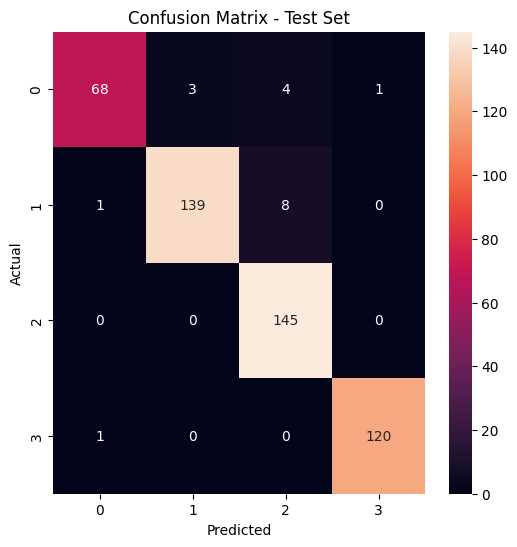

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_gen.reset()
pred = model.predict(test_gen)
y_pred = np.argmax(pred, axis=1)

print(classification_report(test_gen.classes, y_pred))

cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

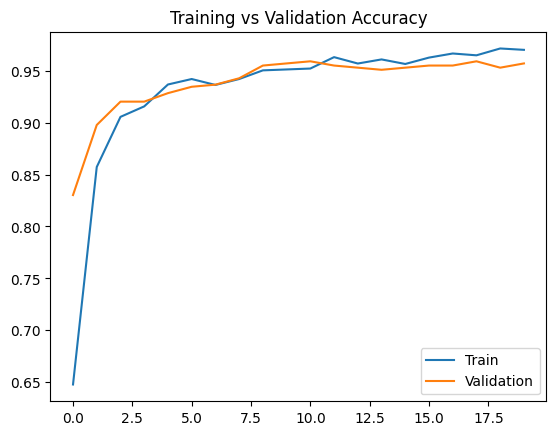

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [ ]:
print("Best Validation Accuracy:", max(history.history['val_accuracy']))

Best Validation Accuracy: 0.9591001868247986
